In [12]:
import pandas as pd
data = pd.read_csv('../dataset/bank/UCI_Credit_Card.csv')
        

data = data.dropna(subset=['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 
                            'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
                            'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                            'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
                            'default.payment.next.month'])


data['AGE'] = pd.to_numeric(data['AGE'], errors='coerce')
data = data.dropna(subset=['AGE'])

Count age privacy data

In [14]:
age = data['AGE'].value_counts()
age

AGE
29    1605
27    1477
28    1409
30    1395
26    1256
31    1217
25    1186
34    1162
32    1158
33    1146
24    1127
35    1113
36    1108
37    1041
39     954
38     944
23     931
40     870
41     824
42     794
44     700
43     670
45     617
46     570
22     560
47     501
48     466
49     452
50     411
51     340
53     325
52     304
54     247
55     209
56     178
57     122
58     122
59      83
21      67
60      67
61      56
62      44
64      31
63      31
66      25
65      24
67      16
69      15
70      10
68       5
73       4
75       3
71       3
72       3
79       1
74       1
Name: count, dtype: int64

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, precision_score, log_loss
from fairlearn.metrics import MetricFrame, equalized_odds_difference
import matplotlib.pyplot as plt
from scipy.stats import expon
import random
import os
import math
from fairlearn.metrics import (
    MetricFrame,
    count,
    false_negative_rate,
    false_positive_rate,
    selection_rate,
)
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds

class CreditCardClient:
    def __init__(self, client_id, epsilon=0.1, bin_size=1, sensitive_attribute='sex', is_fair=True, exf=0.1):
        """Initialize the UCI Credit Card Dataset client"""
        self.client_id = client_id
        self.epsilon = epsilon 
        self.bin_size = bin_size  
        self.is_fair = is_fair 
        self.exf = exf
        self.model = None
        self.original_data = None
        self.protected_data = None
        self.X_train = None
        self.y_train = None
        self.X_test = None
        self.y_test = None
        self.sensitive_attribute = sensitive_attribute 
        self.writer = None
        self.preprocessor = None
    
    def load_data(self):
        """Load the UCI credit card dataset and split the data for clients"""
        data = pd.read_csv('../dataset/bank/UCI_Credit_Card.csv')
        
       
        data = data.dropna(subset=['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 
                                  'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
                                  'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                                  'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
                                  'default.payment.next.month'])
        
        
        data['AGE'] = pd.to_numeric(data['AGE'], errors='coerce')
        data = data.dropna(subset=['AGE'])
        
        n = len(data)
        if self.client_id == 0:
            self.original_data = data.iloc[:n//3]
        elif self.client_id == 1:
            self.original_data = data.iloc[n//3:2*n//3]
        else:
            self.original_data = data.iloc[2*n//3:]
        print(f"Client {self.client_id} load {len(self.original_data)} ")
        return self.original_data
    
    def create_age_candidates(self, data):
        """
        Construct the discrete output candidate set A: age intervals, corresponding to the output space S in the definition (here S = A)
        Returns: list of candidate intervals (e.g., [(18,22), (23,27), ...]), size of the candidate set |A|
        """
        min_age = data['AGE'].min()
        max_age = data['AGE'].max()
        # 构造等宽区间，保证覆盖所有年龄
        bins = []
        current = min_age
        while current < max_age:
            bins.append((current, current + self.bin_size))
            current += self.bin_size
        
        bins[-1] = (bins[-1][0], max_age) if bins[-1][1] > max_age else bins[-1]
        return bins, len(bins)
    
    def exponential_mechanism(self, data, bins, A_size):  
        """
        Construct the exponential mechanism strictly according to the definition:
        - Input a: The original age of the current sample (or the dataset, which needs to be aligned with the defined scenario)
        - Output s: The candidate interval, which belongs to bins
        Here it is simplified to: For a single sample, the input a is its original age, and the output s is the candidate interval
        """
        # Define "input a" as the original age of the sample (needs to be adjusted according to the scenario. If a is a dataset, it needs to be re - adapted).
        a = data['AGE'].values[0] if not data.empty else None

        # Calculate probability: According to the definition formula in the paper
        # π: The probability when s = a (Here, a needs to be mapped to the corresponding interval. Simplified as: If the interval contains a, then s = a corresponds to that interval)
        probabilities = []

        for interval in bins:
            # Determine whether the interval contains the original age a (simplified logic, needs to be strictly aligned according to the definition)
            
            if interval[0] <= a < interval[1]:
                # Case where s = a: Probability π
                prob = math.exp(self.epsilon) / (A_size - 1 + math.exp(self.epsilon))  
            else:
                # Case where s ≠ a: Probability π̄
                prob = 1 / (A_size - 1 + math.exp(self.epsilon))  
            probabilities.append(prob)
        
        # Normalization (theoretically, the formula ensures the sum is 1, but in actual floating - point operations, it may need to be corrected)
        probabilities = np.array(probabilities) / np.sum(probabilities)
        return probabilities
    
    def apply_exponential_mechanism_to_dataset(self):
        """
        Apply the improved exponential mechanism: for each sample, select the output from the candidate intervals, strictly in line with the definition.
        """
        if self.original_data is None:
            self.load_data()
        
        bins, A_size = self.create_age_candidates(self.original_data)
        self.protected_data = self.original_data.copy()
        
        for i, row in self.original_data.iterrows():
            sample_data = pd.DataFrame([row])
            
            probs = self.exponential_mechanism(sample_data, bins, A_size)
            
            selected_idx = np.random.choice(len(bins), p=probs)
            selected_interval = bins[selected_idx]
            
            protected_age = (selected_interval[0] + selected_interval[1] - 1) / 2
            self.protected_data.at[i, 'AGE'] = protected_age
        
        print(f"Client {self.client_id} Apply the exponential mechanism that conforms to the definition to protect age privacy")
        return self.protected_data
    
    def preprocess_data(self, data):
        """Preprocess data for training"""
        processed_data = data.copy()
        # Separate features and targets (default.payment.next.month is the label)
        X = processed_data.drop('default.payment.next.month', axis=1)
        y = processed_data['default.payment.next.month']
        
        
        numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
        # Treat SEX, EDUCATION, MARRIAGE as categorical features (even though they are numerical values).
        categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']
        
        
        self.preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numeric_features),
                ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
            ])
        
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        
        
        X_train_processed = self.preprocessor.fit_transform(X_train)
        X_test_processed = self.preprocessor.transform(X_test)
        
        
        self.X_train = X_train_processed
        self.y_train = y_train
        self.X_test = X_test_processed
        self.y_test = y_test
        
        
        self.sensitive_train = X_train[self.sensitive_attribute].to_numpy()
        self.sensitive_test = X_test[self.sensitive_attribute].to_numpy()
        
        return X_train_processed, y_train, X_test_processed, y_test
    
    def train_base_model(self):
        """Train the base model"""
        if self.protected_data is None:
            self.apply_exponential_mechanism_to_dataset()
        
        self.preprocess_data(self.protected_data)
        
        self.model = LogisticRegression(solver='liblinear', random_state=42, max_iter=100)
        self.model.fit(self.X_train, self.y_train)
        
        y_pred = self.model.predict(self.X_test)
        accuracy = accuracy_score(self.y_test, y_pred)
        print(f"Client {self.client_id} Accuracy of the basic model: {accuracy:.4f}")
        return self.model
    
    def train_fair_model(self):
        """Train a fairness model"""
        if self.protected_data is None:
            self.apply_exponential_mechanism_to_dataset()
        
        self.preprocess_data(self.protected_data)
        
        # Create fairness constraints
        constraint = EqualizedOdds()
        
        # Create a basic model
        base_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=100)
        
        # Train a fair model using Exponentiated Gradient
        fair_model = ExponentiatedGradient(base_model, constraint, eps=self.exf)
        # fair_model = GridSearch(base_model, constraint)
        fair_model.fit(self.X_train, self.y_train, sensitive_features=self.sensitive_train)
        
        y_pred = fair_model.predict(self.X_test)
        accuracy = accuracy_score(self.y_test, y_pred)
        loss = log_loss(self.y_test, y_pred)
        
        metric_frame = MetricFrame(
            metrics={
                'accuracy': accuracy_score,
                'selection_rate': selection_rate,
                'false_positive_rate': false_positive_rate,
                'false_negative_rate': false_negative_rate,
            },
            y_true=self.y_test,
            y_pred=y_pred,
            sensitive_features=self.sensitive_test
        )
        
        # eq_odds_diff = equalized_odds_difference(
        #     self.y_test, y_pred, sensitive_features=self.sensitive_test
        # )
        eq_odds_diff = max(measure_EO(self.y_test, self.sensitive_test, y_pred, 0),measure_EO(self.y_test, self.sensitive_test, y_pred, 1))
        print(f"Client {self.client_id} Accuracy: {accuracy:.4f} Loss:{loss:.4f}")
        print(f"Client {self.client_id} Discrimination: {eq_odds_diff:.4f}")
        self.model = fair_model
        return self.model, accuracy,loss, eq_odds_diff
    
    def train(self):
        """Train the model (fairness or baseline)"""
        if self.is_fair:
            return self.train_fair_model()
        else:
            model = self.train_base_model()
            y_pred = model.predict(self.X_test)
            accuracy = accuracy_score(self.y_test, y_pred)
            loss = log_loss(self.y_test, y_pred)
            eq_odds_diff = max(measure_EO(self.y_test, self.sensitive_test, y_pred, 0),measure_EO(self.y_test, self.sensitive_test, y_pred, 1))
            return model, accuracy, loss, eq_odds_diff
    
    def evaluate(self, model=None):
        """Evaluate model performance"""
        if model is None:
            model = self.model
        if model is None:
            print("The model has not been trained.")
            return None
        
        y_pred = model.predict(self.X_test)
        
        accuracy = accuracy_score(self.y_test, y_pred)
        
        if self.is_fair:
            # eq_odds_diff = equalized_odds_difference(
            #     self.y_test, y_pred, sensitive_features=self.sensitive_test
            # )
            eq_odds_diff = max(measure_EO(self.y_test, self.sensitive_test, y_pred, 0),measure_EO(self.y_test, self.sensitive_test, y_pred, 1))
            return accuracy, eq_odds_diff
        else:
            return accuracy

def measure_EO(Y, A, Yhat, y_value):
    """
    Calculate the Equal Opportunity indicator, cite the paper "Fair Learning with Private Demographic Data"

    Parameters:
    Y: List or Series of true labels
    A: List or Series of sensitive attributes (such as gender, race, etc.)
    Yhat: List or Series of predicted probabilities
    y_value: The true label value to be evaluated

    Returns:
    EO_violation: The degree of equal opportunity violation (maximum group difference)
    """
    
    # Handle possible Pandas Series input
    if isinstance(Y, pd.Series):
        Y = Y.values
    if isinstance(A, pd.Series):
        A = A.values
    if isinstance(Yhat, pd.Series):
        Yhat = Yhat.values
    
    # Get the set of unique values of sensitive attributes
    unique_groups = set(A)
    # Ensure that the group labels are consecutive integers starting from 0
    group_mapping = {group: i for i, group in enumerate(unique_groups)}
    classes = len(unique_groups)
    
    # Initialize statistics
    Yhats = [0] * classes
    conditionals = [0] * classes
    
    # Ensure that the length of the input data is consistent
    if len(Y) != len(A) or len(Y) != len(Yhat):
        raise ValueError("The lengths of the input lists Y, A, and Yhat must be the same.")
    
    # Calculate the sum of prediction probabilities for each group under the given true labels
    for i in range(len(Y)):
        if Y[i] == y_value:
            # Use the mapped group index
            group_idx = group_mapping[A[i]]
            Yhats[group_idx] += Yhat[i]
            conditionals[group_idx] += 1
    
    # Calculate the conditional expectation for each group
    expectations = [0] * classes
    for i in range(classes):
        if conditionals[i] > 0:
            expectations[i] = Yhats[i] / conditionals[i]
    
    # Calculate the differences between groups
    EO_diff = []
    for i in range(classes):
        for j in range(i+1, classes):
            EO_diff.append(abs(expectations[i] - expectations[j]))
    
    # Return the maximum difference as the degree of equal opportunity violation
    EO_violation = max(EO_diff) if EO_diff else 0
    return EO_violation

def federated_aggregation(clients):
    """Federated learning model aggregation"""
    coefs = []
    intercepts = []
    for client in clients:
        if hasattr(client.model, 'predictors_'):
            client_coefs = np.array([p.coef_[0] for p in client.model.predictors_])
            client_intercepts = np.array([p.intercept_[0] for p in client.model.predictors_])
            weights = np.array(client.model.weights_)
            weighted_coef = np.sum(client_coefs * weights[:, np.newaxis], axis=0)
            weighted_intercept = np.sum(client_intercepts * weights)
            coefs.append(weighted_coef)
            intercepts.append(weighted_intercept)
        else:
            
            coefs.append(client.model.coef_[0])
            intercepts.append(client.model.intercept_[0])
    
    
    if any(c.shape != coefs[0].shape for c in coefs):
        max_dim = max(c.shape[0] for c in coefs)
        adjusted_coefs = []
        for c in coefs:
            if c.shape[0] < max_dim:
                adjusted_c = np.zeros(max_dim)
                adjusted_c[:c.shape[0]] = c
                adjusted_coefs.append(adjusted_c)
            else:
                adjusted_coefs.append(c)
        coefs = adjusted_coefs
    
    
    avg_coef = np.mean(coefs, axis=0)
    avg_intercept = np.mean(intercepts)
    
    
    aggregated_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
    first_client = clients[0]
    
    
    all_data = pd.concat([client.original_data for client in clients])
    X_all = all_data.drop('default.payment.next.month', axis=1)
    y_all = all_data['default.payment.next.month']
    
    
    X_all_processed = first_client.preprocessor.transform(X_all)
    X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
        X_all_processed, y_all, test_size=0.2, random_state=42
    )
    
    
    aggregated_model.fit(X_train_all, y_train_all)
    
    
    if avg_coef.shape != aggregated_model.coef_[0].shape:
        if avg_coef.shape[0] > aggregated_model.coef_[0].shape[0]:
            avg_coef = avg_coef[:aggregated_model.coef_[0].shape[0]]
        else:
            new_coef = np.zeros_like(aggregated_model.coef_[0])
            new_coef[:avg_coef.shape[0]] = avg_coef
            avg_coef = new_coef
    
    aggregated_model.coef_[0] = avg_coef
    aggregated_model.intercept_[0] = avg_intercept
    
    aggregated_model.preprocessor = first_client.preprocessor
    return aggregated_model

def run_federated_learning(num_clients=3, num_rounds=5, epsilon=0.1, bin_size=1, sensitive_attribute='AGE', is_fair=True, exf=0.1):
    """Run the federated learning training process"""
    clients = []
    for i in range(num_clients):
        client = CreditCardClient(client_id=i, epsilon=epsilon, bin_size=bin_size, sensitive_attribute=sensitive_attribute, is_fair=is_fair, exf=exf)
        clients.append(client)
    
    global_accuracies = []
    global_losses = []
    global_eq_odds_diffs = []
    
    for round in range(num_rounds):
        print(f"\n===== Federated learning rounds {round+1}/{num_rounds} =====")
        
        local_models = []
        local_accuracies = []
        local_losses = []
        local_eq_odds_diffs = []
        for client in clients:
            print(f"\n Client {client.client_id} Local training is in progress...")
            model, accuracy, loss, eq_odds_diff = client.train()
            local_models.append(model)
            local_accuracies.append(accuracy)
            local_losses.append(loss)
            if eq_odds_diff is not None:
                local_eq_odds_diffs.append(eq_odds_diff)
       
        print("\n Local training results:")
        for i, (acc,lo, eq_odds) in enumerate(zip(local_accuracies, local_losses, local_eq_odds_diffs)):
            print(f"Client {i}: Accuracy = {acc:.4f}, Loss = {lo:.4f}, Discrimination = {eq_odds:.4f}")
        
        print("\n Model aggregation is in progress...")
        global_model = federated_aggregation(clients)
        
        global_accuracy = 0
        global_loss = 0
        global_eq_odds_diff = 0
        for client in clients:
            print(f"Evaluation client {client.client_id} of model...")
            
            X_client = client.original_data.drop('default.payment.next.month', axis=1)
            y_client = client.original_data['default.payment.next.month']
            
            X_client_train, X_client_test, y_client_train, y_client_test = train_test_split(
                X_client, y_client, test_size=0.2, random_state=42
            )
            
            X_client_test_processed = global_model.preprocessor.transform(X_client_test)
            
            y_pred = global_model.predict(X_client_test_processed)
            # Calculate accuracy
            accuracy= accuracy_score(y_client_test, y_pred)
            loss = log_loss(y_client_test, y_pred)

            # If fairness is enabled, calculate the fairness metrics.
            sensitive_client_test = X_client_test[client.sensitive_attribute]
            # eq_odds_diff = equalized_odds_difference(
            #     y_client_test, y_pred, sensitive_features=sensitive_client_test
            # )
            eq_odds_diff = max(measure_EO(y_client_test, sensitive_client_test, y_pred, 0),measure_EO(y_client_test, sensitive_client_test, y_pred, 1))

            print(f"client------------Accuracy: {accuracy:.4f}, Loss:{loss:.4f}, Discrimination: {eq_odds_diff:.4f}")
            global_accuracy += accuracy
            global_loss += loss
            global_eq_odds_diff += eq_odds_diff


        global_accuracy /= num_clients
        global_loss /= num_clients
        global_eq_odds_diff /= num_clients
        print(f"\nGlobal model performance: ------------- Accuracy = {global_accuracy:.4f}, Loss = {global_loss:.4f}, Discrimination = {global_eq_odds_diff:.4f}")


        # Save the results of this round
        global_accuracies.append(global_accuracy)
        global_losses.append(global_loss)
        global_eq_odds_diffs.append(global_eq_odds_diff)

        # Distribute the global model to each client
        for client in clients:
            client.model = global_model

    # Return the final model and performance metrics
    return global_model, global_accuracies, global_losses, global_eq_odds_diffs


# """Analyze the privacy-fairness-utility trade-off"""
eps = [-2, -1, 0, 1, 2]
sensitive_attribute = 'AGE'
results = {}

for ep in eps:
    epsilon = 10**ep
    print(f"\n===== Privacy budget = {epsilon} =====")

    # Without fairness
    print("\n--- Without fairness ---")
    _, accuracies_no_fair, losses_no_fair, eq_odds_diffs_no_fair = run_federated_learning(
        num_clients=3, 
        num_rounds=2, 
        epsilon=epsilon, 
        is_fair=False,
        bin_size=2,
        sensitive_attribute = sensitive_attribute,
        exf=0.1
    )
    
    # With fairness
    print("\n--- With fairness ---")
    _, accuracies_fair, losses_fair, eq_odds_diffs_fair = run_federated_learning(
        num_clients=3, 
        num_rounds=2, 
        epsilon=epsilon, 
        is_fair=True,
        bin_size=2,
        sensitive_attribute=sensitive_attribute,
        exf=0.1
    )

    results[ep] = {
        'no_fair': {
            'accuracy': accuracies_no_fair[-1],
            'loss': losses_no_fair[-1],
            'eq_odds_diff': eq_odds_diffs_no_fair[-1]
        },
        'fair': {
            'accuracy': accuracies_fair[-1],
            'loss': losses_fair[-1],
            'eq_odds_diff': eq_odds_diffs_fair[-1]
        }
    }


===== Privacy budget = 0.01 =====

--- Without fairness ---

===== Federated learning rounds 1/2 =====

 Client 0 Local training is in progress...
Client 0 load 10000 


/tmp/ipykernel_4049649/1648099599.py:133: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '61.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.protected_data.at[i, 'AGE'] = protected_age


Client 0 Apply the exponential mechanism that conforms to the definition to protect age privacy
Client 0 Accuracy of the basic model: 0.8045

 Client 1 Local training is in progress...
Client 1 load 10000 


/tmp/ipykernel_4049649/1648099599.py:133: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '59.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.protected_data.at[i, 'AGE'] = protected_age


Client 1 Apply the exponential mechanism that conforms to the definition to protect age privacy
Client 1 Accuracy of the basic model: 0.7990

 Client 2 Local training is in progress...
Client 2 load 10000 


...

Client 0 Apply the exponential mechanism that conforms to the definition to protect age privacy
Client 0 Accuracy: 0.6715 Loss:11.8403
Client 0 Discrimination: 0.4474

 Client 1 Local training is in progress...
Client 1 load 10000 


/tmp/ipykernel_4049649/1648099599.py:133: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '23.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.protected_data.at[i, 'AGE'] = protected_age


Client 1 Apply the exponential mechanism that conforms to the definition to protect age privacy
Client 1 Accuracy: 0.7255 Loss:9.8940
Client 1 Discrimination: 0.4545

 Client 2 Local training is in progress...
Client 2 load 10000 


/tmp/ipykernel_4049649/1648099599.py:133: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '61.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.protected_data.at[i, 'AGE'] = protected_age


Client 2 Apply the exponential mechanism that conforms to the definition to protect age privacy
Client 2 Accuracy: 0.7345 Loss:9.5696
Client 2 Discrimination: 0.5455

 Local training results:
Client 0: Accuracy = 0.6715, Loss = 11.8403, Discrimination = 0.4474
Client 1: Accuracy = 0.7255, Loss = 9.8940, Discrimination = 0.4545
Client 2: Accuracy = 0.7345, Loss = 9.5696, Discrimination = 0.5455

 Model aggregation is in progress...
Evaluation client 0 of model...
client------------Accuracy: 0.7970, Loss:7.3169, Discrimination: 1.0000
Evaluation client 1 of model...
client------------Accuracy: 0.7875, Loss:7.6593, Discrimination: 1.0000
Evaluation client 2 of model...
client------------Accuracy: 0.8190, Loss:6.5239, Discrimination: 1.0000

Global model performance: ------------- Accuracy = 0.8012, Loss = 7.1667, Discrimination = 1.0000

===== Federated learning rounds 2/2 =====

 Client 0 Local training is in progress...


<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:39: SyntaxWarning: invalid escape sequence '\e'
<>:55: SyntaxWarning: invalid escape sequence '\e'
<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:39: SyntaxWarning: invalid escape sequence '\e'
<>:55: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_4049649/1817579679.py:22: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Privacy Budget $log(\epsilon_p)$', fontsize=20)
/tmp/ipykernel_4049649/1817579679.py:39: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Privacy Budget $log(\epsilon_p)$', fontsize=20)
/tmp/ipykernel_4049649/1817579679.py:55: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Privacy Budget $log(\epsilon_p)$', fontsize=20)


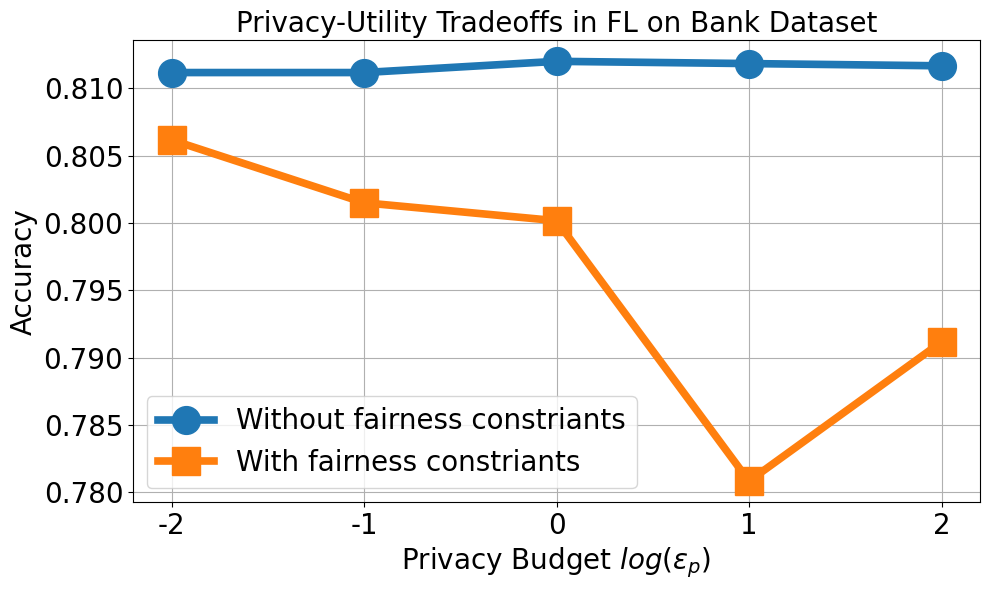

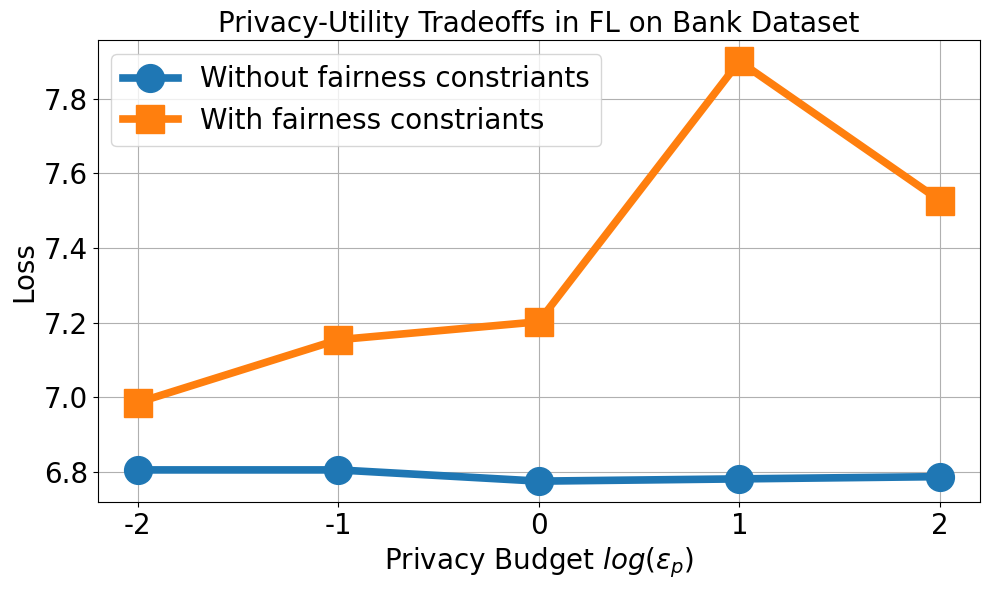

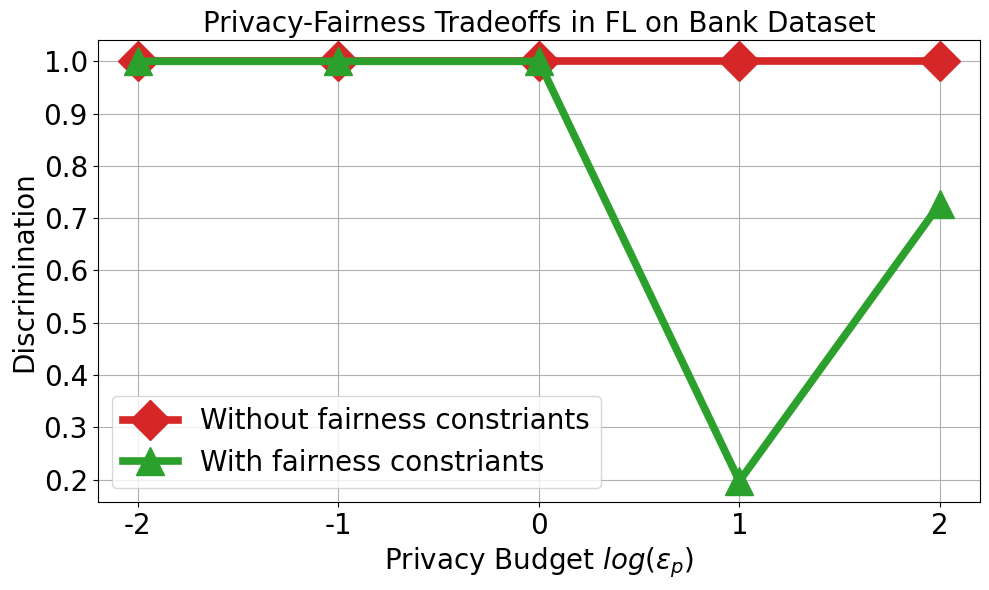

In [9]:
def plot_tradeoff(results):
    """Draw the privacy-fairness-utility tradeoffs chart in FL on Bank Dataset"""
    epsilons = list(results.keys())
    no_fair_accuracies = [results[eps]['no_fair']['accuracy'] for eps in epsilons]
    fair_accuracies = [results[eps]['fair']['accuracy'] for eps in epsilons]
    no_fair_losses = [results[eps]['no_fair']['loss'] for eps in epsilons]
    fair_losses = [results[eps]['fair']['loss'] for eps in epsilons]
    no_eq_odds_diffs = [results[eps]['no_fair']['eq_odds_diff'] for eps in epsilons]
    eq_odds_diffs = [results[eps]['fair']['eq_odds_diff'] for eps in epsilons]

    x_positions = np.arange(len(epsilons))
    
    # Create a chart
    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    plt.figure(figsize=(10,6))
    
    # Draw accuracy comparison
    plt.plot(x_positions, no_fair_accuracies, color='#1f77b4', linestyle='-', label='Without fairness constriants', marker='o',linewidth=5.5, markersize=20)
    plt.plot(x_positions, fair_accuracies, color='#ff7f0e', linestyle='-', label='With fairness constriants', marker='s', linewidth=5.5, markersize=20)
    # plt.set_xscale('log')
    plt.xticks(x_positions, epsilons, fontsize=20)
    plt.xlabel('Privacy Budget $log(\epsilon_p)$', fontsize=20)
    plt.ylabel('Accuracy', fontsize=20)
    plt.title('Privacy-Utility Tradeoffs in FL on Bank Dataset', fontsize=20)
    plt.grid(True)
    plt.xticks(fontsize=20)  
    plt.yticks(fontsize=20)
    plt.legend(fontsize=20)
    plt.tight_layout()
    plt.show()


    # Draw accuracy comparison
    plt.figure(figsize=(10,6))
    plt.plot(x_positions, no_fair_losses, color='#1f77b4', linestyle='-', label='Without fairness constriants', marker='o',linewidth=5.5, markersize=20)
    plt.plot(x_positions, fair_losses, color='#ff7f0e', linestyle='-', label='With fairness constriants', marker='s', linewidth=5.5, markersize=20)
    # plt.set_xscale('log')
    plt.xticks(x_positions, epsilons, fontsize=20)
    plt.xlabel('Privacy Budget $log(\epsilon_p)$', fontsize=20)
    plt.ylabel('Loss', fontsize=20)
    plt.title('Privacy-Utility Tradeoffs in FL on Bank Dataset', fontsize=20)
    plt.grid(True)
    plt.xticks(fontsize=20)  
    plt.yticks(fontsize=20)
    plt.legend(fontsize=20)
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(10,6))
    # Draw fairness indicators
    plt.plot(x_positions, no_eq_odds_diffs, color='#d62728',label='Without fairness constriants', linestyle='-', marker='D', linewidth=5.5, markersize=20)
    plt.plot(x_positions, eq_odds_diffs, color='#2ca02c',label='With fairness constriants',linestyle='-', marker='^', linewidth=5.5, markersize=20)
    # plt.xlabel('log')
    plt.xticks(x_positions, epsilons, fontsize=20)
    plt.xlabel('Privacy Budget $log(\epsilon_p)$', fontsize=20)
    plt.ylabel('Discrimination', fontsize=20)
    plt.title('Privacy-Fairness Tradeoffs in FL on Bank Dataset', fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=20)
    plt.xticks(fontsize=20)  
    plt.yticks(fontsize=20)
    plt.tight_layout()
    # plt.savefig('privacy_fairness_utility_tradeoff.png')
    plt.show()


# Draw a chart
plot_tradeoff(results)
